In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    print(os.path.join(dirname))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/global-wheat-detection
/kaggle/input/competitions/global-wheat-detection/test
/kaggle/input/competitions/global-wheat-detection/train


In [5]:
import cv2
import matplotlib.pyplot as plt
import ast # 문자열 형태의 리스트를 실제 리스트로 변환

TRAIN_DIR = '/kaggle/input/competitions/global-wheat-detection/train'
train_df = pd.read_csv('/kaggle/input/competitions/global-wheat-detection/train.csv')

train_df['bbox'] = train_df['bbox'].apply(ast.literal_eval)

train_df[['x', 'y', 'w', 'h']] = pd.DataFrame(train_df['bbox'].tolist(), index=train_df.index)

train_dataset = pd.read_csv('/kaggle/input/competitions/global-wheat-detection/train.csv')

In [6]:
train_df.head()

,image_id,width,height,bbox,source,x,y,w,h
0,b6ab77fd7,1024,1024,"[834.0, 222.0, 56.0, 36.0]",usask_1,834.0,222.0,56.0,36.0
1,b6ab77fd7,1024,1024,"[226.0, 548.0, 130.0, 58.0]",usask_1,226.0,548.0,130.0,58.0
2,b6ab77fd7,1024,1024,"[377.0, 504.0, 74.0, 160.0]",usask_1,377.0,504.0,74.0,160.0
3,b6ab77fd7,1024,1024,"[834.0, 95.0, 109.0, 107.0]",usask_1,834.0,95.0,109.0,107.0
4,b6ab77fd7,1024,1024,"[26.0, 144.0, 124.0, 117.0]",usask_1,26.0,144.0,124.0,117.0


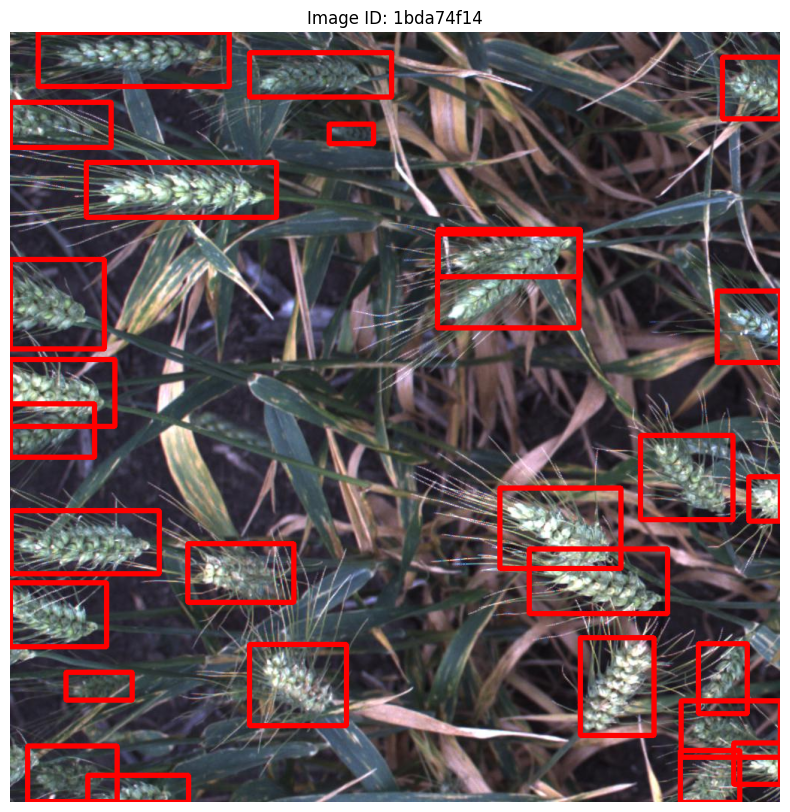

In [7]:
def show_image_with_bboxes(image_id):
    # 이미지 로드
    image_path = os.path.join(TRAIN_DIR, f'{image_id}.jpg')
    image = cv2.imread(image_path)
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    
    # 해당 이미지의 bbox 가져오기
    bboxes = train_df[train_df['image_id'] == image_id][['x', 'y', 'w', 'h']].values
    
    # 박스 그리기
    for box in bboxes:
        x, y, w, h = box.astype(int)
        # cv2.rectangle(이미지, (x_min, y_min), (x_max, y_max), 색상, 두께)
        cv2.rectangle(image, (x, y), (x + w, y + h), (255, 0, 0), 5)
        
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.title(f"Image ID: {image_id}")
    plt.axis('off')
    plt.show()

# 샘플 이미지 하나 출력해보기
sample_id = train_df['image_id'].unique()[10]
show_image_with_bboxes(sample_id)

이미지당 평균 박스 개수: 43.82
최대 박스 개수: 116
최소 박스 개수: 1


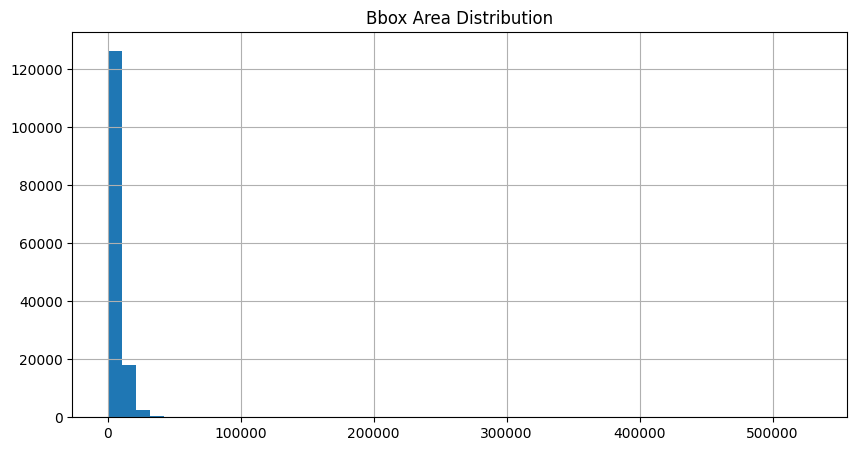

source
ethz_1       51489
arvalis_1    45716
rres_1       20236
arvalis_3    16665
usask_1       5807
arvalis_2     4179
inrae_1       3701
Name: count, dtype: int64


In [8]:
# 1. 이미지당 박스 개수 분포
bbox_counts = train_df.groupby('image_id').count()['bbox']
print(f"이미지당 평균 박스 개수: {bbox_counts.mean():.2f}")
print(f"최대 박스 개수: {bbox_counts.max()}")
print(f"최소 박스 개수: {bbox_counts.min()}")

# 2. 박스 크기(면적) 분포
train_df['area'] = train_df['w'] * train_df['h']
plt.figure(figsize=(10, 5))
train_df['area'].hist(bins=50)
plt.title("Bbox Area Distribution")
plt.show()

# 3. 데이터 출처(Source) 확인
print(train_df['source'].value_counts())